In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, spherical_yn , hankel1,lpmv,jn
import cmath
import matplotlib.gridspec as gridspec

In [2]:
def MieCoef(x, M, n):
    # Computing spherical Bessel functions for n and M*n
    j_n_x = spherical_jn(n, x)
    j_n_Mx = spherical_jn(n, M*x)

    # Computing Riccati-Bessel functions
    psi_n_x = x * j_n_x
    zeta_n_x = x * cmath.sqrt(np.pi/(2*x))*hankel1(n+1/2,x)

    psi_n_Mx = M * x * j_n_Mx
    zeta_n_Mx = M * x * cmath.sqrt(np.pi/(2*M*x))*hankel1(n+1/2,M*x)

    # Computing Riccati-Bessel function derivatives using numdifftools
    #psi_n_x_prime = nd.Derivative(lambda x: x * spherical_jn(n, x), n=1, order=1)(x)
    psi_n_x_prime = 1/2* (  x* (spherical_jn(n-1,x)-spherical_jn(n+1,x)) + spherical_jn(n,x) ) 
    
    zeta_n_x_prime = 1/2* cmath.sqrt(np.pi/(2*x))*(  x* (hankel1(n+1/2-1,x)-hankel1(n+1/2+1,x)) + hankel1(n+1/2,x) )

    #psi_n_Mx_prime = nd.Derivative(lambda x: M * x * spherical_jn(n, M * x), n=1, order=1)(x)
    psi_n_Mx_prime = 1/2* (  M*x* (spherical_jn(n-1,M*x)-spherical_jn(n+1,M*x)) + spherical_jn(n,M*x) ) 
    
    zeta_n_Mx_prime= 1/2* cmath.sqrt(np.pi/(2*M*x))*(  x* (hankel1(n+1/2-1,M*x)-hankel1(n+1/2+1,M*x)) + hankel1(n+1/2,M*x) )

    # Calculating coefficients a_n, b_n, c_n, d_n
    a_n = (M * psi_n_Mx * psi_n_x_prime - psi_n_Mx_prime * psi_n_x) / (psi_n_Mx_prime * zeta_n_x - M * psi_n_Mx * zeta_n_x_prime)
    b_n = (M * psi_n_Mx_prime * psi_n_x - psi_n_Mx * psi_n_x_prime) / (psi_n_Mx * zeta_n_x_prime - M * psi_n_Mx_prime * zeta_n_x)
    
    #c_n = (psi_n_x * zeta_n_x_prime - psi_n_x_prime * zeta_n_x) / (psi_n_Mx_prime * zeta_n_x - M * psi_n_Mx * zeta_n_x_prime)
    #d_n = (psi_n_x_prime * zeta_n_x - psi_n_x * zeta_n_x_prime) / (psi_n_Mx * zeta_n_x_prime - M * psi_n_Mx_prime * zeta_n_x)

    return a_n, b_n

def MieCoefCond2(x, n, k1):
    jn = spherical_jn(n, x)
    jn1 = spherical_jn(n+1,x)
    jn_1 = spherical_jn(n-1,x)
    
    hankeln = np.sqrt(np.pi/(2*x))*hankel1(n+1/2,x)
    hankeln1 = np.sqrt(np.pi/(2*x))*hankel1(n+1+1/2,x)
    hankeln_1 = np.sqrt(np.pi/(2*x))*hankel1(n-1+1/2,x)
    
    a = -(jn + x *1/2* (  x* (jn_1-jn1) + jn ))/(hankeln + x  *1/2* ( x*(hankeln_1-hankeln1) + hankeln))

    b = - jn/hankeln  

    
    return a, b


def E1_SCATnm(n, a_n, b_n, k, x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    phi = np.sign(y) * np.arccos(x/np.sqrt(x**2+y**2))
    theta = np.arccos(z / r)

    kr = k * r
    hn = np.sqrt(np.pi / (2 * kr)) * hankel1(n + 1 / 2, kr)
    hn1 = np.sqrt(np.pi / (2 * kr)) * hankel1(n + 1 / 2 + 1, kr)
    Pn1 = lpmv(1, n + 1, np.cos(theta))
    Pn = lpmv(1, n, np.cos(theta))

    dP = (n * Pn1 - (n + 1) * np.cos(theta) * Pn) / np.sin(theta)
    P = Pn / np.sin(theta)

    # Replace zero values of dP and P at theta=0 with -1/2*n*(n+1)

    zero_theta_indices = (np.where(abs(theta) < 10**(-10))[0])
    dP[zero_theta_indices] = -0.5 * n * (n + 1)
    P[zero_theta_indices] = -0.5 * n * (n + 1)

    zero_theta_indices = (np.isnan(phi))
    phi[zero_theta_indices] = 0
    
    Gn = 1j**n
    prefac = -Gn / (n * (n + 1)) * (2 * n + 1) * 1j

    term_r = -a_n / kr * hn * Pn * n * (n + 1) * np.cos(phi)
    term_the = (-a_n / kr * ((n + 1) * hn - kr * hn1) * dP - 1j * b_n * hn * P) * np.cos(phi)
    term_phi = (a_n / kr * ((n + 1) * hn - kr * hn1) * P + 1j * b_n * hn * dP) * np.sin(phi)

    return prefac * (np.array([term_r * np.cos(phi) * np.sin(theta), term_r * np.sin(theta) * np.sin(phi), term_r * np.cos(theta)]) +
                     np.array([term_the * np.cos(phi) * np.cos(theta), term_the * np.cos(theta) * np.sin(phi), -term_the * np.sin(theta)]) +
                     np.array([-term_phi * np.sin(phi), term_phi * np.cos(phi), np.zeros_like(r)]))


<>:63: SyntaxWarning: invalid escape sequence '\e'
<>:64: SyntaxWarning: invalid escape sequence '\e'
<>:63: SyntaxWarning: invalid escape sequence '\e'
<>:64: SyntaxWarning: invalid escape sequence '\e'
C:\Users\vinic\AppData\Local\Temp\ipykernel_34092\3963513199.py:63: SyntaxWarning: invalid escape sequence '\e'
  lns3 = ax3.plot(N0s, eps_theoretical, 'b^:', label='Theoretical $\epsilon$')
C:\Users\vinic\AppData\Local\Temp\ipykernel_34092\3963513199.py:64: SyntaxWarning: invalid escape sequence '\e'
  ax3.set_ylabel('Expected Precision ($\epsilon$)', color='b', fontsize=14)


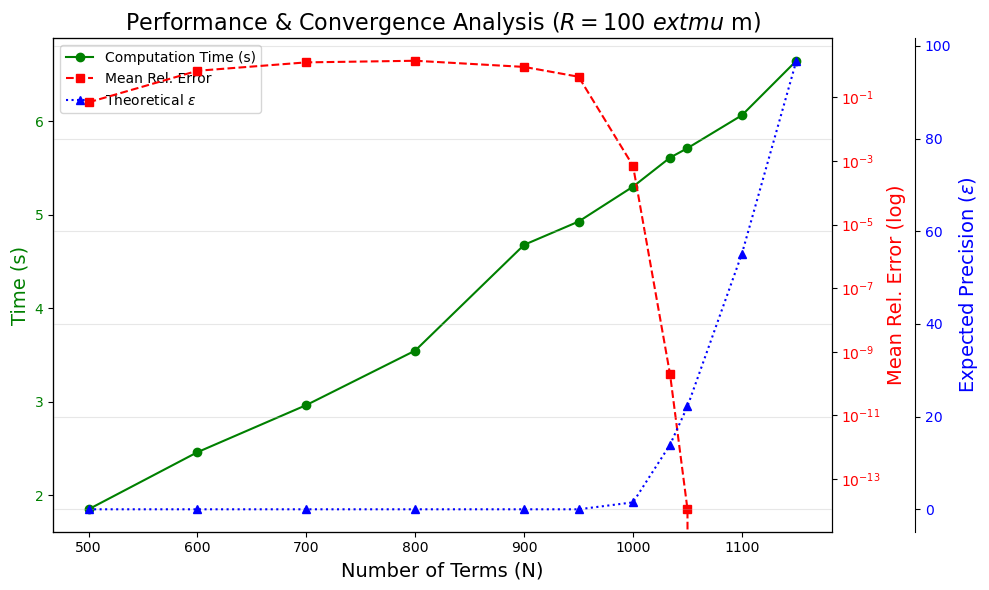

In [ ]:
import time

# --- Setup and Constants ---
R1 = 100
lamb = 0.632
k = 2 * np.pi / lamb
x_s = k * R1
y = 0
zi = 10000 # evaluation distance
N_spatial = 300 
x_eval = np.linspace(-0.2*R1, 0.2*R1, N_spatial)
N0s = [500,600,700,800,900,950,1000, 1034,1050,1100,1150]

intensities = []
times = []

# --- Calculation Loop ---
for n_lim in N0s:
    start_time = time.time()
    E_total = np.zeros((3, N_spatial), dtype=complex)
    for i in range(1, n_lim + 1):
        a_n, b_n = MieCoefCond2(x_s, i, k) # Use your existing MieCoef function
        if np.isnan(np.abs(a_n)) or np.isnan(np.abs(b_n)):
            break
        E_total += E1_SCATnm(i, a_n, b_n, k, x_eval, y, zi)
    
    intensities.append(np.sum(np.abs(E_total)**2, axis=0))
    times.append(time.time() - start_time)

# --- Error and Epsilon Analysis ---
ref_intensity = intensities[-1] # N=1034 reference
max_ref = np.max(ref_intensity)
mean_rel_errors = [np.mean(np.abs(I - ref_intensity)) / max_ref for I in intensities]

# Calculate theoretical epsilon: eps = ((N - x_s + 4.1) / (0.76 * x_s^(1/3)))^(3/2)
eps_theoretical = []
for N in N0s:
    val = (N - x_s + 4.1) / (0.76 * x_s**(1/3))
    eps_theoretical.append(val**(1.5) if val > 0 else 0)

# --- Combined Plotting ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left Axis: Computation Time
lns1 = ax1.plot(N0s, times, 'go-', label='Computation Time (s)')
ax1.set_xlabel('Number of Terms (N)', fontsize=14)
ax1.set_ylabel('Time (s)', color='g', fontsize=14)
ax1.tick_params(axis='y', labelcolor='g')

# Right Axis 1: Mean Relative Error
ax2 = ax1.twinx()
lns2 = ax2.plot(N0s[:-1], mean_rel_errors[:-1], 'rs--', label='Mean Rel. Error')
ax2.set_ylabel('Mean Rel. Error (log)', color='r', fontsize=14)
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='r')

# Right Axis 2: Theoretical Precision (Epsilon)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
lns3 = ax3.plot(N0s, eps_theoretical, 'b^:', label='Theoretical $\epsilon$')
ax3.set_ylabel('Expected Precision ($\epsilon$)', color='b', fontsize=14)
ax3.tick_params(axis='y', labelcolor='b')

plt.title('Performance & Convergence Analysis ($R=100~\textmu$ m)', fontsize=16)
lns = lns1 + lns2 + lns3
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()